In [1]:
import os
from pathlib import Path

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import sklearn
import tensorflow as tf
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import mllabs

import sys
print(sys.version)

for i in [pd, pl, np, plt, sns, scipy, sklearn, tf, xgb, lgb, cb, mllabs]:
    if hasattr(i, '__version__'):
        print(i.__name__, i.__version__)
    else:
        print(i.__name__)

2026-03-06 07:15:50.005967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


3.12.6 (main, Sep 30 2024, 02:19:13) [GCC 9.4.0]
pandas 2.2.3
polars 1.12.0
numpy 2.1.3
matplotlib.pyplot
seaborn 0.13.2
scipy 1.15.2
sklearn 1.5.2
tensorflow 2.20.0
xgboost 2.1.2
lightgbm
catboost 1.2.8
mllabs 0.6.0


In [29]:
from IPython.display import Markdown

from lightgbm import early_stopping as lgb_early_stopping

from mllabs import Connector, Experimenter
from mllabs.collector import MetricCollector, ModelAttrCollector
from mllabs.adapter import LightGBMAdapter

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

from scipy.stats import mannwhitneyu, kruskal, spearmanr

In [3]:
from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from sklearn.pipeline import make_pipeline

data_path = Path('data')

dict_expr = {
    'gender': (pl.col('gender') == 'Male').cast(pl.Int8),
    'No_Internet': (pl.col('DeviceProtection') == 'No internet service').cast(pl.Int8),
    'DSL_Y': (pl.col('InternetService') == 'DSL').cast(pl.Int8)
}
for i in ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService']:
    dict_expr[i] = (pl.col(i) == 'Yes').cast(pl.Int8)

for i in ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'MultipleLines']:
    dict_expr[i + '_Y'] = (pl.col(i) == 'Yes').cast(pl.Int8)

loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    ExprProcessor(dict_expr=dict_expr),
    PandasConverter(index_col = 'id')
)
# Target은 train만 처리
df_train = loader.fit_transform([data_path / 'train.csv']).assign(
    Churn = lambda x: (x['Churn'] == 'Yes').astype('int8')
)
df_test = loader.transform([data_path / 'test.csv'])

In [8]:
X_bin = ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService', 'gender', 'SeniorCitizen', ]
X_tri = ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']
X_bin2 = ['{}_Y'.format(i) for i in X_tri] + ['No_Internet', 'DSL_Y', 'MultipleLines_Y']
X_tri.append('InternetService')
X_tri.append('MultipleLines')
X_num = ['TotalCharges', 'MonthlyCharges', 'tenure']
X_nom = ['PaymentMethod', 'Contract']
X_all = X_bin + X_tri + X_bin2 + X_num + X_nom

target = 'Churn'

# Train/Test의 차이 분석

In [9]:
df_is_test = pd.concat([
    df_train[X_all].assign(is_test = 0),
    df_test[X_all].assign(is_test = 1)
])
df_is_test['is_test'].value_counts().pipe(
    lambda x: pd.concat([x, (x / x.sum()).rename('ratio')], axis=1)
)

,count,ratio
is_test,,
0,594194,0.7
1,254655,0.3


In [10]:
if os.path.exists('exp/is_test'):
    e_is_test = Experimenter.load('exp/is_test', df_is_test)
    if e_is_test.status == 'closed':
        e_is_test.reopen_exp()
else:
    e_is_test = Experimenter.create(
        df_is_test, 'exp/is_test', title = 'Train/Test셋 여부를 구분', 
        sp = StratifiedShuffleSplit(n_splits=1, random_state = 1), 
        sp_v = StratifiedShuffleSplit(n_splits=1, train_size = 0.1, random_state = 1), splitter_params = {'y': 'is_test'}
    )
Markdown(
    e_is_test.desc_spec()
)

Loaded: 2 node(s), 1 group(s), 1 fold(s)
Initialize 'lgb1'
Initialize 'lgb2'
Building 0 node(s)
Build 1/1 (100%)       
Build complete: 0 node(s)


## Train/Test셋 여부를 구분

| 항목 | 값 |
|------|-----|
| **Outer Splitter (sp)** | `StratifiedShuffleSplit(n_splits=1, random_state=1)` |
| **Inner Splitter (sp_v)** | `StratifiedShuffleSplit(n_splits=1, random_state=1)` |
| **Splitter Params** | `{y='is_test'}` |
| **Outer Folds** | 1 |
| **Inner Folds** | 1 |

In [12]:
e_is_test.add_collector(
    MetricCollector(
        'AUC', Connector(edges = {'y': [(None, 'is_test')]}), slice(-1, None), roc_auc_score, include_train = True
    )
)
e_is_test.add_collector(
    ModelAttrCollector(
        'lgb_feature_importance', Connector(processor = lgb.LGBMClassifier), 'feature_importances'
    )
)
e_is_test.set_grp('clf', role = 'head', edges = {'y': [(None, 'is_test')]}, method = 'predict_proba')
e_is_test.set_node(
    'lgb1', grp='clf', processor=lgb.LGBMClassifier , edges = {'X': [(None, X_all)]}, 
    params={'verbose': -1, 'categorical_features': X_nom}
)

{'result': 'update',
 'affected_nodes': [],
 'old_obj': <mllabs._pipeline.PipelineNode at 0x7f8336568290>,
 'obj': <mllabs._pipeline.PipelineNode at 0x7f833654f860>}

In [13]:
e_is_test.exp()

Experimenting 2 node(s)
Exp 0/1 (0%) > lgb2 1/2 (50%) > 1/5000 (0%) valid_0-binary_logloss: 0.6107                                  Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.610147
Evaluated only: binary_logloss
Exp 1/1 (100%)                                                            
Experimentation complete: 2 node(s)


In [14]:
e_is_test.get_collector('AUC').get_metrics_agg()[0]

,valid,train_sub,valid_sub
lgb1,0.509518,0.650932,0.510088
lgb2,0.506674,0.549849,0.510162


In [16]:
e_is_test.set_node(
    'lgb2', grp='clf', processor=lgb.LGBMClassifier , edges = {'X': [(None, X_all)]}, 
    adapter=LightGBMAdapter(eval_mode='valid'),
    params={'verbose': -1, 'categorical_features': X_nom, 'early_stopping': lgb_early_stopping(50, first_metric_only=True), 'n_estimators': 5000}
)
e_is_test.exp()

Experimenting 1 node(s)
Exp 0/1 (0%) > lgb2 0/1 (0%) > 1/5000 (0%) valid_0-binary_logloss: 0.6107Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.610147
Evaluated only: binary_logloss
Exp 1/1 (100%)                                                           
Experimentation complete: 1 node(s)


In [17]:
e_is_test.get_collector('AUC').get_metrics_agg()[0]

,valid,train_sub,valid_sub
lgb1,0.509518,0.650932,0.510088
lgb2,0.506674,0.549849,0.510162


- Train / Test의 구분력을 보이지 않아 Test를 따로 분석할 필요가 없다고 할 수 있다.

In [18]:
e_is_test.close_exp()

Finalize 'lgb1'
Finalize 'lgb2'


# Target: Churn

In [19]:
df_train[target].value_counts().pipe(
    lambda x: pd.concat([x, (x / x.sum()).rename('ratio')], axis=1)
)

,count,ratio
Churn,,
0,460377,0.774792
1,133817,0.225208


# Categorical Variables

## Information gain

In [20]:
y_prob = df_train[target].value_counts(normalize = True)
H_target = -y_prob.dot(np.log(y_prob))

pd.Series({
    i: H_target - pd.crosstab(index = df_train[i], columns = df_train[target], normalize = 'index').apply(
        lambda x: -x.dot(np.log(x)), axis = 1
    ).dot(df_train[i].value_counts(normalize = True)) for i in X_bin + X_tri + X_bin2 + X_nom
}, name = 'IG').sort_values(ascending = False)

Contract              0.133328
PaymentMethod         0.112203
OnlineSecurity        0.105165
InternetService       0.103407
TechSupport           0.100455
OnlineBackup          0.079472
DeviceProtection      0.074180
StreamingMovies       0.055795
StreamingTV           0.055749
No_Internet           0.055674
PaperlessBilling      0.045913
Dependents            0.033733
Partner               0.026463
OnlineSecurity_Y      0.024069
SeniorCitizen         0.023878
DSL_Y                 0.020890
TechSupport_Y         0.020675
StreamingTV_Y         0.006786
MultipleLines         0.006633
MultipleLines_Y       0.006596
StreamingMovies_Y     0.006481
OnlineBackup_Y        0.005195
DeviceProtection_Y    0.002823
PhoneService          0.000647
gender                0.000023
Name: IG, dtype: float64

- Contract와 PaymentMethod 만으로 target에 대한 AUC를 얼마나 낼 수 있을까?

In [21]:
roc_auc_score(
    df_train[target], df_train.groupby('Contract', observed=True)[target].transform('mean')
)

np.float64(0.7894150683901222)

In [22]:
roc_auc_score(
    df_train[target], df_train.groupby('PaymentMethod', observed=True)[target].transform('mean')
)

np.float64(0.776768714041246)

## Correlation

In [23]:
X_val = X_bin + X_bin2 + X_nom
ig_list = []
for j in X_val[:-1]:
    prob = df_train[j].value_counts(normalize = True)
    H = -prob.dot(np.log(prob))
    ig_list.append(
        pd.Series({
            i: H - pd.crosstab(index = df_train[i], columns = df_train[j], normalize = 'index').apply(
                lambda x: -x.dot(np.log(x + 1e-10)), axis = 1
            ).dot(df_train[i].value_counts(normalize = True)) for i in X_val if i > j
        }, name = j).to_frame().unstack().rename('MI').reset_index().rename(columns={'level_0': 'value_1', 'level_1': 'value_2'})
    )

In [24]:
pd.concat(ig_list).sort_values('MI', ascending = False).iloc[:30]

,value_1,value_2,MI
1,StreamingMovies_Y,StreamingTV_Y,0.228824
1,Dependents,Partner,0.162079
7,No_Internet,StreamingMovies_Y,0.148113
8,No_Internet,StreamingTV_Y,0.147144
10,No_Internet,PaymentMethod,0.122630
10,DeviceProtection_Y,No_Internet,0.119651
5,No_Internet,OnlineBackup_Y,0.117609
7,DeviceProtection_Y,StreamingMovies_Y,0.111997
8,DeviceProtection_Y,StreamingTV_Y,0.111674
0,No_Internet,PaperlessBilling,0.108854


In [25]:
df_train.pivot_table(index = 'StreamingMovies_Y', columns = 'StreamingTV_Y', aggfunc = 'size', observed = True)

StreamingTV_Y,0,1
StreamingMovies_Y,,
0,303920,48839
1,49973,191462


- Contract와 PaymentMethod와 상관성이 없어, 두 개의 변수로 한다면 AUC의 향상이 꽤 있을 것으로 예상됨

In [26]:
roc_auc_score(
    df_train[target], df_train.groupby(['Contract', 'PaymentMethod'], observed=True)[target].transform('mean')
)

np.float64(0.8549348614717375)

- OnlineSecurity까지 넣어봄


In [27]:
roc_auc_score(
    df_train[target], df_train.groupby(['Contract', 'PaymentMethod', 'OnlineSecurity'], observed=True)[target].transform('mean')
)

np.float64(0.8694661817805394)

# Numerical Variables

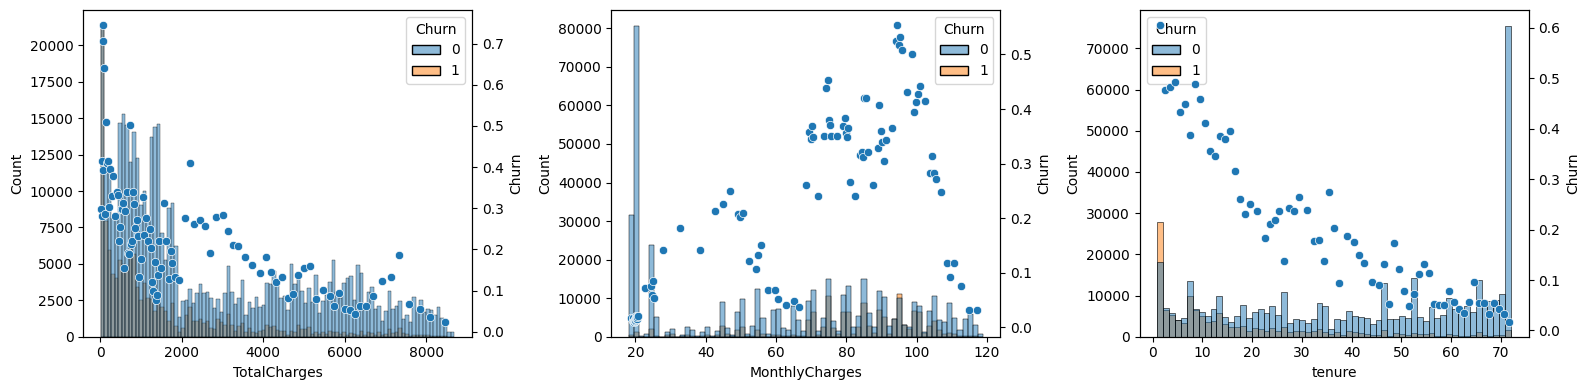

In [66]:
_, axes = plt.subplots(1, 3, figsize = (16, 4))
for i, ax in zip(X_num, axes.flatten()):
    sns.histplot(df_train, x = i, ax = ax, hue = target)
    df_train.groupby(pd.qcut(df_train[i], q = 100, duplicates = 'drop'), observed = True)[target].mean().reset_index().assign(
        q_median = lambda x: (x[i].cat.categories.left + x[i].cat.categories.right) / 2
    ).pipe(
        lambda x: sns.scatterplot(x, x = 'q_median', y = target, ax = ax.twinx())
    )
plt.tight_layout()
plt.show()

In [68]:
roc_auc_score(df_train[target], -df_train['tenure'])

np.float64(0.7936764118576458)

In [70]:
roc_auc_score(df_train[target], df_train['MonthlyCharges'])

np.float64(0.6790063142581958)

In [72]:
roc_auc_score(df_train[target], -df_train['TotalCharges'])

np.float64(0.6678535948669334)

In [76]:
df_train[X_num].corr().unstack().rename('corr').reset_index().query('level_0 < level_1')

,level_0,level_1,corr
2,TotalCharges,tenure,0.769703
3,MonthlyCharges,TotalCharges,0.634237
5,MonthlyCharges,tenure,0.124043


In [94]:
df_train.query('tenure == 1').pipe(
    lambda x: x['MonthlyCharges'] - x['TotalCharges']
).value_counts(normalize=True)

 0.000000      0.911281
-1.000000      0.022685
 1.000000      0.016894
-2.000000      0.004797
 2.000000      0.003290
                 ...   
-422.750000    0.000034
 5.400002      0.000034
 30.199999     0.000034
-75.199997     0.000034
 30.750000     0.000034
Name: proportion, Length: 418, dtype: float64

In [98]:
roc_auc_score(df_train[target], df_train['MonthlyCharges'] / df_train['tenure'])

np.float64(0.8557175787629427)

In [99]:
roc_auc_score(df_train[target], df_train['TotalCharges'] / df_train['tenure'])

np.float64(0.6834943642074567)

<Axes: xlabel='q_median', ylabel='Churn'>

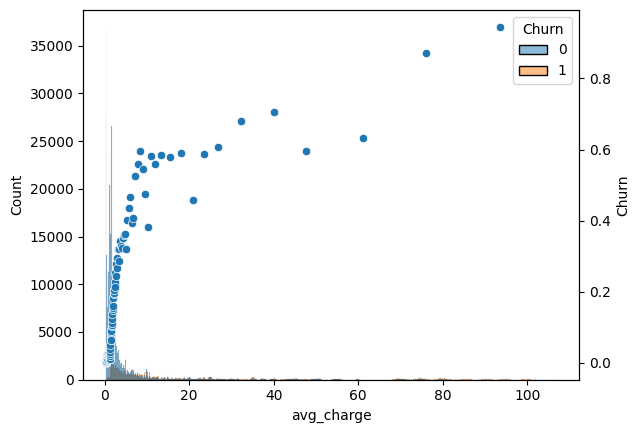

In [83]:
ax = plt.gca()
avg_charge = (df_train['MonthlyCharges'] / df_train['tenure']).rename('avg_charge')
sns.histplot(x=avg_charge, ax = ax, hue = df_train[target])
df_train.groupby(pd.qcut(avg_charge, q = 100, duplicates = 'drop'), observed = True)[target].mean().reset_index().assign(
    q_median = lambda x: (x['avg_charge'].cat.categories.left + x['avg_charge'].cat.categories.right) / 2
).pipe(
    lambda x: sns.scatterplot(x, x = 'q_median', y = target, ax = ax.twinx())
)

- Monthly Charge는 어떠한 요금제를 나타낼 수도 있지 않을까?

In [91]:
df_train['MonthlyCharges'].value_counts()

MonthlyCharges
20.049999    7436
19.950001    5718
19.700001    5705
20.000000    5493
19.850000    5114
             ... 
32.450001       1
31.299999       1
89.239998       1
21.700001       1
46.150002       1
Name: count, Length: 1921, dtype: int64

In [92]:
roc_auc_score(
    df_train[target], df_train.groupby('MonthlyCharges')[target].transform('mean')
)

np.float64(0.779535041604032)

In [100]:
from sklearn.preprocessing import TargetEncoder

tgt = TargetEncoder()
roc_auc_score(
    df_train[target], tgt.fit_transform(df_train[['MonthlyCharges']], df_train[target])[:, 0]
)

np.float64(0.7749372928999412)

- 범주형으로 시도해볼만하지만, 저빈도가 보이므로 이를 OOV를 감안한 처리가 필요하지 않을까함

# ML pilot & Analysis

In [120]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from mllabs.nn import NNClassifier
from mllabs import ColSelector
from mllabs.adapter import XGBoostAdapter, LightGBMAdapter, CatBoostAdapter
from mllabs.collector import SHAPCollector
from mllabs.filter import RandomFilter
from mllabs.col import ohe_drop_first

In [102]:
df_train['mt_ratio'] = df_train['TotalCharges'] / df_train['tenure']
X_num = X_num[:3] # idempotent
X_num.append('mt_ratio')

## 실험을 위한 기반 설정 작업

In [103]:
if os.path.exists('exp/analysis'):
    e_aml = Experimenter.load('exp/analysis', df_train)
    if e_aml.status == 'closed':
        e_aml.reopen_exp()
else:
    e_aml = Experimenter.create(
        df_train, 'exp/analysis', title='파일럿과 데이터 탐색을 위한 ML 실험',
        sp=StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=1),
        sp_v=StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=1),
        splitter_params={'y': target}
    )
Markdown(
    e_aml.desc_spec()
)

Loaded: 0 node(s), 0 group(s), 1 fold(s)


## 데이터 탐색을 위한 ML 실험

| 항목 | 값 |
|------|-----|
| **Outer Splitter (sp)** | `StratifiedShuffleSplit(n_splits=1, random_state=1, test_size=0.3)` |
| **Inner Splitter (sp_v)** | `StratifiedShuffleSplit(n_splits=1, random_state=1, test_size=0.1)` |
| **Splitter Params** | `{y='Churn'}` |
| **Outer Folds** | 1 |
| **Inner Folds** | 1 |

In [271]:
# Pipeline 구성

e_aml.set_grp('pre', role='stage', method='transform')
y_edges = {'y': [(None, target)]}
e_aml.set_grp(
    'clf', role='head', method='predict_proba', edges=y_edges
)

# XGBoost
e_aml.set_grp('xgb', parent='clf', processor=xgb.XGBClassifier,
    adapter=XGBoostAdapter(eval_mode='valid'),
    params={
        'n_estimators': 10000, 'learning_rate': 0.05, 'early_stopping_rounds': 50, 'eval_metric': 'auc', 'enable_categorical': True,
        'verbosity': 0, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('xgb_evals_results', Connector(processor=xgb.XGBClassifier), 'evals_result')
)

# LightGBM
e_aml.set_grp('lgb', parent='clf', processor=lgb.LGBMClassifier,
    adapter=LightGBMAdapter(eval_mode='valid'),
    params={
        'n_estimators': 10000, 'learning_rate': 0.05,
        'early_stopping': lgb_early_stopping(50, first_metric_only=True),
        'eval_metric': 'auc', 'verbose': -1, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('lgb_evals_results', Connector(processor=lgb.LGBMClassifier), 'evals_result')
)

# CatBoost
e_aml.set_grp('cb', parent='clf', processor=cb.CatBoostClassifier,
    adapter=CatBoostAdapter(eval_mode='valid'),
    params={
        'iterations': 10000, 'learning_rate': 0.05, 'early_stopping_rounds': 50,
        'eval_metric': 'AUC', 'verbose': 0, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('cb_evals_results', Connector('_base$', processor=cb.CatBoostClassifier), 'evals_result') # GPU는 수집할 수 없어서 제외(GPU는 _gpu로 끝나게 설정)
)

# LogisticRegression
e_aml.set_grp('lr', parent='clf', processor=LogisticRegression,
    params={
        'max_iter': 1000, 'random_state': 1,
    }
)

# DecisionTreeClassifier
e_aml.set_grp('dt', parent='clf', processor=DecisionTreeClassifier,
    params={
        'max_depth': 4, 'random_state': 1, # 주요 요인이 무엇인지 파악하기 위함
    }
)

## Neural network
e_aml.set_grp('nn', parent = 'clf', processor = NNClassifier, params = {'metrics': ['auc'], 'early_stopping': 10})
e_aml.add_collector(
    ModelAttrCollector('nn_evals', Connector(processor=NNClassifier), result_key='evals_result')
)

Group 'lgb' updated, 2 node(s) affected


In [109]:
# Collector 구성

e_aml.add_collector(
    MetricCollector(
        'AUC',
        Connector(edges=y_edges), slice(-1, None), roc_auc_score, include_train = True
    )
)

# Feature importance — LGB
e_aml.add_collector(
    ModelAttrCollector(
        'lgb_feature_importance',
        Connector(processor=lgb.LGBMClassifier, edges=y_edges),
        'feature_importances'
    )
)

# Feature importance — XGB
e_aml.add_collector(
    ModelAttrCollector(
        'xgb_feature_importance_gain',
        Connector(processor=xgb.XGBClassifier, edges=y_edges),
        'feature_importances', params = {'importance_type': 'gain'}
    )
)

e_aml.add_collector(
    ModelAttrCollector(
        'xgb_feature_importance_cover',
        Connector(processor=xgb.XGBClassifier, edges=y_edges),
        'feature_importances', params = {'importance_type': 'cover'}
    )
)

# CatBoost feature importance (PredictionValuesChange)
e_aml.add_collector(
    ModelAttrCollector(
        'cb_feature_importance',
        Connector(processor=cb.CatBoostClassifier, edges=y_edges),
        'feature_importances_pvc'
    )
)

# CatBoost feature interaction importance
e_aml.add_collector(
    ModelAttrCollector(
        'cb_interaction',
        Connector(processor=cb.CatBoostClassifier, edges=y_edges),
        'feature_importances_interaction'
    )
)

# LogisticRegression coef
e_aml.add_collector(
    ModelAttrCollector(
        'lr_coef',
        Connector(processor=LogisticRegression, edges=y_edges),
        'coef'
    )
)

Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       


In [112]:
set(df_train.columns) - set(X_bin + X_nom + X_tri + X_num)

{'Churn',
 'DSL_Y',
 'DeviceProtection_Y',
 'MultipleLines_Y',
 'No_Internet',
 'OnlineBackup_Y',
 'OnlineSecurity_Y',
 'StreamingMovies_Y',
 'StreamingTV_Y',
 'TechSupport_Y',
 'mt_ratio'}

## 실험 수행

In [127]:
e_aml.set_node('ohe', processor = OneHotEncoder, grp='pre', edges = {'X': [(None, X_nom)]}, params = {'sparse_output': False})
e_aml.set_node('std', processor = StandardScaler, grp='pre', edges = {'X': [(None, X_num)]})
e_aml.build()

Affected 2 dependent node(s): ['dt_base', 'lr_base']
Building 1 node(s)
Build 1/1 (100%)               
Build complete: 1 node(s)


In [205]:
e_aml.set_node('xgb_base', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]})
e_aml.set_node('lgb_base', grp='lgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'categorical_features': ColSelector(col_type = 'category')})
e_aml.set_node('cb_base', grp='cb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'cat_features': ColSelector(col_type = 'category')})
e_aml.set_node('dt_base', grp='dt', edges = {'X': [(None, X_bin + X_bin2 + X_num), ('ohe', None)]})
e_aml.set_node('lr_base', grp='lr', edges = {'X': [(None, X_bin + X_bin2), ('std', None), ('ohe', ohe_drop_first)]})
e_aml.set_node('nn_base', grp = 'nn', edges = {'X': [(None, X_bin + X_nom + X_bin2), ('std', None)]})
e_aml.exp()

Experimenting 2 node(s)
Exp 1/1 (100%)                                                                                              
Experimentation complete: 2 node(s)


## 결과 분석

### 학습시간 (초)

In [206]:
pd.Series({
    i: next(e_aml.get_objs(i, 0))[2]['fit_time']
    for i in ['xgb_base', 'lgb_base', 'cb_base', 'dt_base', 'lr_base', 'nn_base']
}).sort_values(ascending = False)

cb_base     180.061842
nn_base      83.447415
xgb_base      4.832705
lgb_base      3.591892
lr_base       3.043586
dt_base       0.532842
dtype: float64

- CatBoost가 가장 오래걸림..

In [278]:
e_aml.set_node('cb_base_gpu', grp='cb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'task_type': 'GPU', 'cat_features': ColSelector(col_type = 'category')})
e_aml.exp()

Experimenting 3 node(s)
Exp 0/1 (0%) > lgb_base2 0/3 (0%) > 1/10000 (0%) valid_0-auc: 0.9031, valid_0-binary_logloss: 0.5129Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[514]	valid_0's auc: 0.916802	valid_0's binary_logloss: 0.29748
Evaluated only: auc
Exp 0/1 (0%) > cb_base_gpu 1/3 (33%)                                                                

Default metric period is 5 because AUC is/are not implemented for GPU


Exp 0/1 (0%) > lgb_base 2/3 (66%) > 1/10000 (0%) valid_0-auc: 0.9030, valid_0-binary_logloss: 0.5129Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[655]	valid_0's auc: 0.917028	valid_0's binary_logloss: 0.2971
Evaluated only: auc
Exp 1/1 (100%)                                                                                      
Experimentation complete: 3 node(s)


- CatBoost의 학습을 gpu로 하니 개선이 시간 절약이 되긴 함

In [279]:
pd.Series({
    i: next(e_aml.get_objs(i, 0))[2]['fit_time']
    for i in ['xgb_base', 'lgb_base', 'cb_base', 'cb_base_gpu', 'dt_base', 'lr_base', 'nn_base']
}).sort_values(ascending = False)

cb_base        180.061842
nn_base         83.447415
cb_base_gpu     44.408360
xgb_base         4.832705
lgb_base         4.033649
lr_base          3.043586
dt_base          0.532842
dtype: float64

### AUC

- Early Stopping를 제외한 기본 파라미터의 성능이니 참고용으로 봄

In [282]:
e_aml.get_collector('AUC').get_metrics_agg('.*_base$|._gpu$')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
cb_base,0.915630,0.920066,0.917128
xgb_base,0.915341,0.923464,0.916858
lgb_base,0.915304,0.924048,0.917028
cb_base_gpu,0.915183,0.918814,0.916705
nn_base,0.912461,0.915349,0.914568
lr_base,0.907455,0.908050,0.908985
dt_base,0.894513,0.894691,0.895593


- CB에서 GPU 사용에 의해 달리 작동함에 따라 성능의 차이가 확인 됨

### Plot tree

In [210]:
from sklearn.tree import plot_tree

In [211]:
proc = next(e_aml.get_objs('dt_base', 0))[0]
proc.obj, proc.X_[:3]

(DecisionTreeClassifier(max_depth=4, random_state=1),
 ['Dependents', 'PaperlessBilling', 'Partner'])

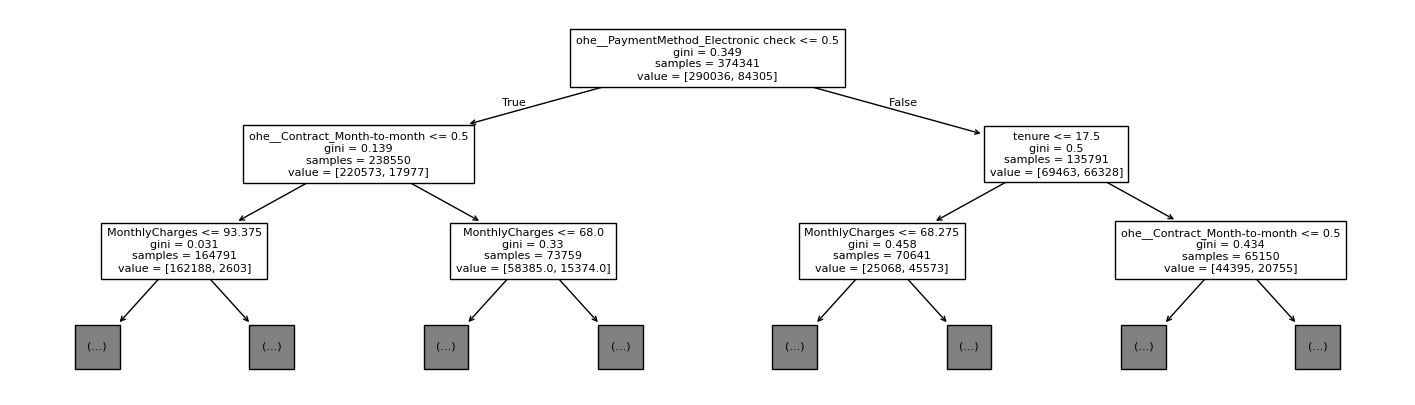

In [212]:
plt.figure(figsize = (18, 5))

plot_tree(
    proc.obj, max_depth = 2, feature_names = proc.X_, fontsize = 8
)
plt.show()

### Feature Importance

In [158]:
# 연결하지 않고 개별적으로 사용가능
shap_col = SHAPCollector(
    'shap',
    Connector(processor=xgb.XGBClassifier),
    data_filter=RandomFilter(frac=0.1, random_state=1)
)
e_aml.collect(shap_col)

Collect 1/1 (100%)                    


In [165]:
pd.concat([
    e_aml.collectors['lgb_feature_importance'].get_attrs_agg('lgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('lgb'),
    e_aml.collectors['xgb_feature_importance_gain'].get_attrs_agg('xgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_gain'),
    e_aml.collectors['xgb_feature_importance_cover'].get_attrs_agg('xgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_cover'),
    e_aml.collectors['cb_feature_importance'].get_attrs_agg('cb_base').pipe(
        lambda x: x / x.sum()
    ).rename('cb'),
    shap_col.get_feature_importance_agg('xgb_base').pipe(lambda x: x / x.sum()).rename('xgb_shap')
], axis = 1).pipe(
    lambda x: x.iloc[np.argsort(-x.sum(axis=1))]
)

,lgb,xgb_gain,xgb_cover,cb,xgb_shap
Contract,0.032672,0.406592,0.094159,0.186267,0.317941
InternetService,0.008397,0.402633,0.113932,0.024179,0.095076
tenure,0.115420,0.025136,0.066208,0.212822,0.104601
MonthlyCharges,0.205089,0.002884,0.054904,0.129565,0.036242
TotalCharges,0.213893,0.002992,0.079085,0.074844,0.045774
mt_ratio,0.190789,0.004613,0.037469,0.109728,0.065527
PaymentMethod,0.022188,0.047091,0.026106,0.090005,0.081865
OnlineSecurity,0.017964,0.019187,0.036924,0.034015,0.044242
PaperlessBilling,0.020560,0.010841,0.053100,0.030867,0.036905
MultipleLines,0.021730,0.007999,0.050658,0.020075,0.034480


- 전반적으로 Contract가 중요한 변수로 보이지만, 모델과 방법에 따라 중요성을 보이는 게 차이가 남. Boosting에서 공선성이 존재하기도 하니 컬럼 샘플링이 효과성이 있을 듯함

### Interaction

In [167]:
e_aml.get_collector('cb_interaction').get_attrs_agg('cb_base').sort_values(ascending = False).iloc[:20]

feat1           feat2         
TotalCharges    MonthlyCharges    9.190316
                mt_ratio          6.533304
MonthlyCharges  mt_ratio          6.027533
TotalCharges    tenure            5.735956
MonthlyCharges  tenure            5.137461
tenure          mt_ratio          3.559544
Contract        TotalCharges      1.992771
PaymentMethod   TotalCharges      1.888722
Contract        tenure            1.762484
PaymentMethod   tenure            1.562745
MultipleLines   TotalCharges      1.412097
PaymentMethod   MultipleLines     1.386799
Contract        MonthlyCharges    1.356203
PaymentMethod   MonthlyCharges    1.312305
OnlineBackup    TotalCharges      1.280190
OnlineSecurity  TotalCharges      1.131521
PaymentMethod   mt_ratio          1.081056
MultipleLines   MonthlyCharges    1.079257
Contract        mt_ratio          1.067172
PaymentMethod   Contract          1.051492
dtype: float64

### Coefficient of LR

In [213]:
e_aml.get_collector('lr_coef').get_attrs_agg('lr_base').pipe(
    lambda x: x.iloc[np.argsort(-x.abs())]
)

0  No_Internet                                  -2.057735
   std__tenure                                  -1.843811
   intercept                                    -1.583221
   ohe__Contract_Two year                       -1.394397
   DSL_Y                                        -0.991800
   std__TotalCharges                             0.826869
   ohe__Contract_One year                       -0.762041
   ohe__PaymentMethod_Electronic check           0.674031
   PhoneService                                 -0.515616
   SeniorCitizen                                 0.439795
   PaperlessBilling                              0.406255
   OnlineSecurity_Y                             -0.376700
   StreamingTV_Y                                 0.376152
   MultipleLines_Y                               0.352179
   StreamingMovies_Y                             0.337247
   Dependents                                   -0.333309
   TechSupport_Y                                -0.227949
   OnlineBacku

### Learning Curve

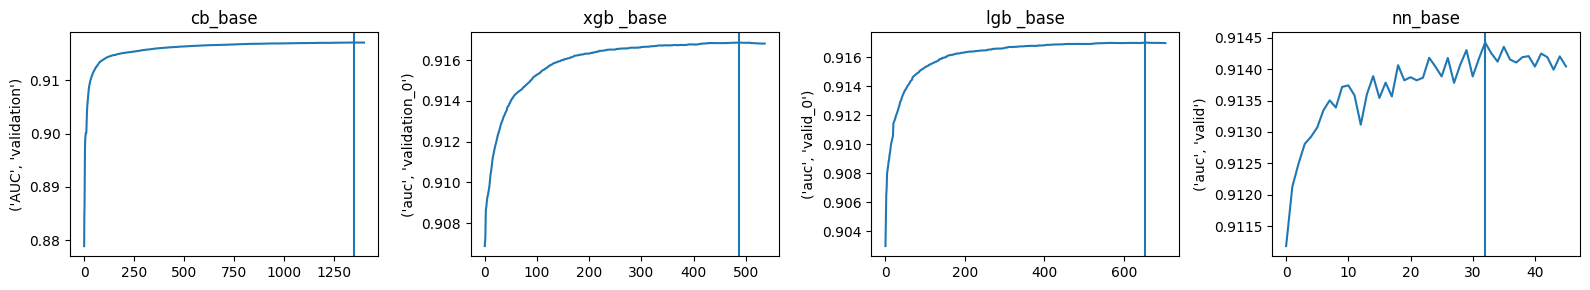

In [259]:
_, axes = plt.subplots(1, 4, figsize = (16, 3))
d = e_aml.collectors['cb_evals_results'].get_attrs()
s_valid = d['cb_base'][0][0].unstack(level=[1, 2])[('AUC', 'validation')]
sns.lineplot(s_valid, ax=axes[0])
axes[0].axvline(s_valid.argmax())
axes[0].set_title('cb_base')
d = e_aml.collectors['xgb_evals_results'].get_attrs()
s_valid = d['xgb_base'][0][0].unstack(level=[1, 2])[('auc', 'validation_0')]
sns.lineplot(s_valid, ax=axes[1])
axes[1].axvline(s_valid.argmax())
axes[1].set_title('xgb _base')
d = e_aml.collectors['lgb_evals_results'].get_attrs()
s_valid = d['lgb_base'][0][0].unstack(level=[1, 2])[('auc', 'valid_0')]
sns.lineplot(s_valid, ax=axes[2])
axes[2].axvline(s_valid.argmax())
axes[2].set_title('lgb _base')
d = e_aml.collectors['nn_evals'].get_attrs()
s_valid = d['nn_base'][0][0].unstack(level=[1, 2])[('auc', 'valid')]
sns.lineplot(s_valid, ax=axes[3])
axes[3].axvline(s_valid.argmax())
axes[3].set_title('nn_base')
plt.tight_layout()
plt.show()

## 속성 공학 파일럿

### mt_ratio를 빼면?

- 분석 과정에서 실수로 파생변수를 포함, 순수하게 제공된 변수만으로 사용했을 때를 본다
- 처음부터 포함하고 갔지만, 이름 뺀 모델의 성능은?

In [216]:
e_aml.set_node('xgb_base2', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]})
e_aml.set_node('lgb_base2', grp='lgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]}, params={'categorical_features': ColSelector(col_type = 'category')})
e_aml.set_node('cb_base2', grp='cb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]}, params={'cat_features': ColSelector(col_type = 'category')})
e_aml.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                    
Experimentation complete: 1 node(s)


In [217]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*|lgb.*|cb.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
cb_base,0.915630,0.920066,0.917128
cb_base2,0.915564,0.919768,0.917174
xgb_base,0.915341,0.923464,0.916858
lgb_base,0.915304,0.924048,0.917028
xgb_base2,0.915288,0.922595,0.916740
lgb_base2,0.915226,0.921835,0.916802
xgb_base4,0.915199,0.923093,0.916715
xgb_base3,0.909429,0.922122,0.910883


In [218]:
e_aml.get_collector('cb_interaction').get_attrs_agg('cb_base2').sort_values(ascending = False).iloc[:20]

feat1             feat2         
TotalCharges      MonthlyCharges    13.631532
                  tenure            11.926549
MonthlyCharges    tenure             9.702997
Contract          TotalCharges       2.228840
PaymentMethod     TotalCharges       2.073301
Contract          tenure             2.068442
PaymentMethod     MonthlyCharges     1.830208
Contract          MonthlyCharges     1.786114
PaymentMethod     tenure             1.729345
                  MultipleLines      1.479524
TechSupport       TotalCharges       1.425270
MultipleLines     TotalCharges       1.326108
DeviceProtection  TotalCharges       1.292589
OnlineBackup      TotalCharges       1.206204
OnlineSecurity    TotalCharges       1.150577
InternetService   TotalCharges       1.116274
                  MonthlyCharges     1.090336
OnlineBackup      MonthlyCharges     1.076645
MultipleLines     MonthlyCharges     1.064926
                  tenure             1.049830
dtype: float64

- mt_ratio는 딱히 유의미성이 보이지 않는 듯

### MonthlyCharges를 Categorical 변수로

In [214]:
from mllabs.processor import CatConverter
from sklearn.preprocessing import TargetEncoder

In [182]:
e_aml.set_node('n2c', processor = CatConverter, grp='pre', edges = {'X': [(None, ['MonthlyCharges'])]})
e_aml.build()

Building 0 node(s)
Build 1/1 (100%)       
Build complete: 0 node(s)


In [183]:
e_aml.set_node('xgb_base3', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + ['TotalCharges', 'tenure']), ('n2c', None)]}, desc = "MonthlyCharges를 카테고리변수로")
e_aml.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                                                           
Experimentation complete: 1 node(s)


In [184]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
xgb_base,0.915341,0.923464,0.916858
xgb_base2,0.915288,0.922595,0.916740
xgb_base3,0.909429,0.922122,0.910883


In [188]:
e_aml.set_node('tgt', grp='pre', processor = TargetEncoder, method = 'fit_transform', edges = {'X': [(None, ['MonthlyCharges'])], 'y': [(None, target)]})
e_aml.set_node('xgb_base4', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num), ('tgt', None)]}, desc = "MonthlyCharges를 타겟인코딩")
e_aml.build()
e_aml.exp()

Affected 1 dependent node(s): ['xgb_base4']
Building 1 node(s)
Build 1/1 (100%)               
Build complete: 1 node(s)
Experimenting 1 node(s)
Exp 1/1 (100%)                                                           
Experimentation complete: 1 node(s)


In [189]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
xgb_base,0.915341,0.923464,0.916858
xgb_base2,0.915288,0.922595,0.916740
xgb_base4,0.915199,0.923093,0.916715
xgb_base3,0.909429,0.922122,0.910883


In [198]:
e_aml.set_node('lr_base2', grp='lr', edges = {'X': [(None, X_bin + X_bin2 + X_num), ('ohe', ohe_drop_first), ('tgt', None)]}, desc = "MonthlyCharges를 타겟인코딩")
e_aml.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                    
Experimentation complete: 1 node(s)


In [215]:
e_aml.get_collector('AUC').get_metrics_agg('lr.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
lr_base,0.907455,0.908050,0.908985
lr_base2,0.907381,0.908015,0.908945


- 큰 효과성은 보이지 않는듯

-----

본격적인 모델링은 다음 노트에서...